In [49]:
#ukljucivanje biblioteka

from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import hist

In [50]:
#potrebne funkcije koje sam napravila za EM algoritam:

def normalnaGustinaVjerovatnoceUTacki(xi, a, sigma):
    eksponent = -0.5 * ((xi - a) / sigma)**2
    fi = (sigma * np.sqrt(2 * np.pi))**(-1)
    fi = fi * np.exp(eksponent)
    return fi

def LogLikelihood(y, mi1, mi2, sigma1, sigma2, pi):
    N = np.size(y)
    LogLikelihood = 0
    for i in range(N):
        fi1 = normalnaGustinaVjerovatnoceUTacki(y[i], mi1, sigma1)
        fi2 = normalnaGustinaVjerovatnoceUTacki(y[i], mi2, sigma2)
        LogLikelihood = LogLikelihood + np.log((1 - pi) * fi1 + pi * fi2)/np.log(10)
    return LogLikelihood

def EM2GausAlgoritam(y, mi1poc, mi2poc, sigma1poc, sigma2poc, pipoc, epsilon, maxIter):
    
    #postavljanje pocetnih parametara:
    mi1_hat = mi1poc; mi2_hat = mi2poc; sigma1_hat = sigma1poc; sigma2_hat = sigma2poc;
    pi_hat = pipoc
    
    #postavljanje dodatnih parametara i vrijednosti koje se vracaju iz funkcije:
    k = 0
    LL = []
    mi1_niz = []
    mi2_niz = []
    sigma1_niz = []
    sigma2_niz = []
    pi_niz = []
    N = np.size(y)
    
    ##Expectation step i Maximization step:
    while k < maxIter:
        
        #upisujemo sve varijable koje se mijenjaju kroz iteracije u odgovarajuce nizove:
        mi1_niz.append(mi1_hat)
        mi2_niz.append(mi2_hat)
        sigma1_niz.append(sigma1_hat)
        sigma2_niz.append(sigma2_hat)
        pi_niz.append(pi_hat)
        
        #odredjujemo log likelyhood:
        pomocna = LogLikelihood(y, mi1_hat, mi2_hat, sigma1_hat, sigma2_hat, pi_hat)
        LL.append(pomocna)
        
        #E step:
        gama_hat = []
        for yi in y:
            fi1 = normalnaGustinaVjerovatnoceUTacki(yi, mi1_hat, sigma1_hat)
            fi2 = normalnaGustinaVjerovatnoceUTacki(yi, mi2_hat, sigma2_hat)
            gama_i = (pi_hat * fi2) / ((1 - pi_hat) * fi1 + pi_hat * fi2)
            gama_hat.append(gama_i)

        #M step:
        #prvo izracunamo sumu svih gami:
        suma_gami = 0
        for i in range(N):
            suma_gami = suma_gami + gama_hat[i]
        #sad racunamo mi1, mi2, sigma1 i sigma2:
        mi1 = 0; mi2 = 0; sigma1 = 0; sigma2 = 0;
        for i in range(N):
            mi1 = mi1 + (1-gama_hat[i]) * y[i]
            mi2 = mi2 + gama_hat[i] * y[i]
        mi1 = mi1 / (N - suma_gami)
        mi2 = mi2 / suma_gami
        for i in range(N):
            sigma1 = sigma1 + (1 - gama_hat[i]) * (y[i] - mi1)**2
            sigma2 = sigma2 + gama_hat[i] * (y[i] - mi2)**2
        sigma1 = sigma1 / (N - suma_gami)
        sigma2 = sigma2 / suma_gami
        sigma1 = np.sqrt(sigma1)
        sigma2 = np.sqrt(sigma2)
        pi = suma_gami / N
        
        #sada gledamo da li je algoritam konvergirao na osnovu log likelihood-a:
        if k > 1 and (LL[-1] - LL[-2])**2 < epsilon:
            break
        
        #ako algoritam nije konvergirao, postavljamo vrijednosti parametara za narednu iteraciju:
        mi1_hat = mi1; mi2_hat = mi2; sigma1_hat = sigma1; sigma2_hat = sigma2; pi_hat = pi;
        k = k + 1

    return mi1_hat, mi2_hat, sigma1_hat, sigma2_hat, pi_hat, k, LL, mi1_niz, mi2_niz, sigma1_niz, sigma2_niz, pi_niz

def PlotajIzvornuIDobivenuFunkciju(y, mi1, mi2, sigma1, sigma2, pi, autobinovi = False):
    N = 1000
    x = np.linspace(np.min(y),np.max(y), N)
    novaFunkcija = []
    for i in range(N):
        fi1 = normalnaGustinaVjerovatnoceUTacki(x[i], mi1, sigma1)
        fi2 = normalnaGustinaVjerovatnoceUTacki(x[i], mi2, sigma2)
        novaFunkcija.append((1 - pi) * fi1 + pi * fi2)
    #plotanje:
    if autobinovi:
        plt.figure(); plt.hist(y, density = True); plt.plot(x, novaFunkcija); 
        plt.legend(['Aproksimirana distribucija pocetnog niza', 'Histogram pocetnog niza uzoraka'])
        return
    
    binovi = int(np.sqrt(np.size(y)))
    plt.figure(); plt.hist(y, bins = binovi, density = True); plt.plot(x, novaFunkcija); 
    plt.legend(['Aproksimirana distribucija pocetnog niza', 'Histogram pocetnog niza uzoraka'])

mi1_hat = 4.654939817329245 mi2_hat = 1.0823203015443046

sigma1_hat^2 = 0.8202175155189518 sigma2_hat^2 = 0.8100092424896149

pi_hat = 0.554338296753698

Broj iteracija nakon kojih algoritam konvergira je 38


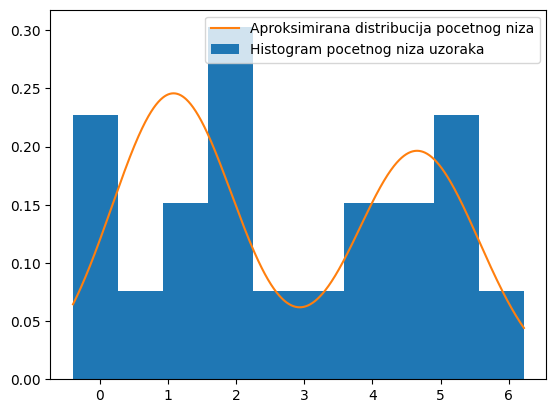

In [51]:
#primjer iz knjige:

y1 = [-0.39, 0.12, 0.94, 1.67, 1.76, 2.44, 3.72, 4.28, 4.92, 5.53, 0.06, 0.48, 1.01, 1.68, 1.80, 3.25, 4.12, 4.60, 5.28, 6.22]
N = 20

#mi1 i mi2 nasumicno izaberemo iz niza y:
mi1poc = 0.94
mi2poc = 0.12

#sigma1 i sigma2 na pocetku mogu biti jednaki korijenu iz varijanse cijelog niza:
sigma1poc = np.sqrt(np.var(y1))
sigma2poc = sigma1poc

#pi_kapa moze biti na pocetku jednako 0.5
pipoc = 0.5

[mi1_hat, mi2_hat, sigma1_hat, sigma2_hat, pi_hat, k, LL, mi1_niz, mi2_niz, sigma1_niz, sigma2_niz, pi_niz] = EM2GausAlgoritam(y1, mi1poc, mi2poc, sigma1poc, sigma2poc, pipoc, 1e-10, 100)
    
#novi parametri koje dobijemo su:
print('mi1_hat =', mi1_hat, 'mi2_hat =', mi2_hat)
print()
print('sigma1_hat^2 =', sigma1_hat**2, 'sigma2_hat^2 =', sigma2_hat**2)
print()
print('pi_hat =', pi_hat)
print()
print('Broj iteracija nakon kojih algoritam konvergira je', k+1)

PlotajIzvornuIDobivenuFunkciju(y1, mi1_hat, mi2_hat, sigma1_hat, sigma2_hat, pi_hat, autobinovi = True); plt.savefig('primjer1.png');

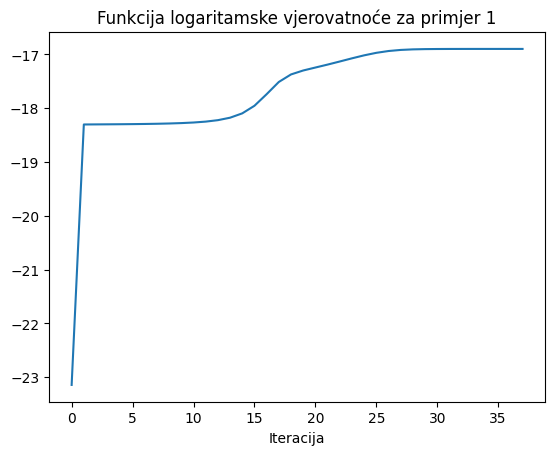

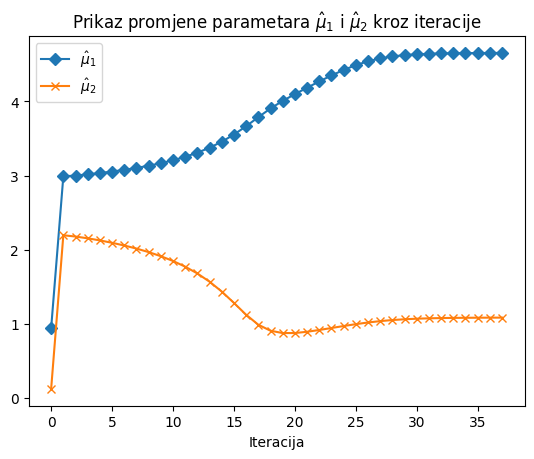

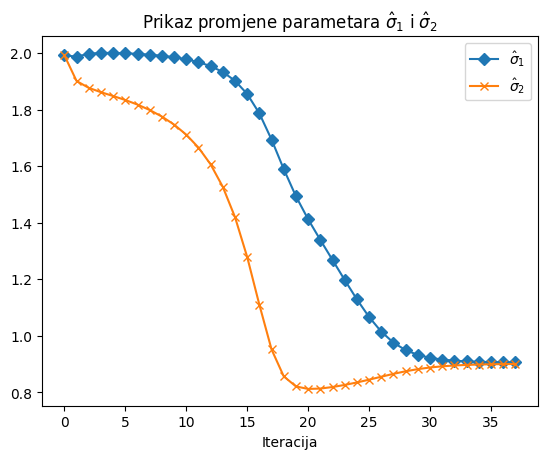

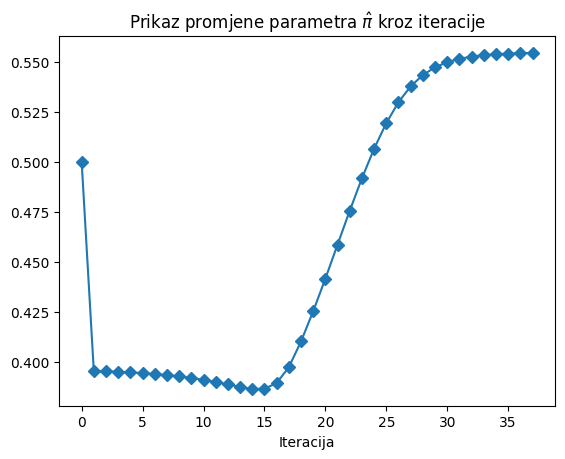

In [52]:
#plot log likelihood funkcije:
plt.figure(); plt.plot(range(0, k+1), LL); plt.title('Funkcija logaritamske vjerovatnoće za primjer 1'); plt.xlabel('Iteracija'); plt.savefig('primjer1_loglikelihood.png');

#kako se parametri mi1 i mi2 mijenjaju kroz iteracije:
plt.figure(); plt.plot(range(0, k+1), mi1_niz, marker = 'D'); plt.plot(range(0, k+1), mi2_niz, marker = 'x'); 
plt.xlabel('Iteracija'); plt.legend(['$\hat{\mu}_1$', '$\hat{\mu}_2$']); plt.title('Prikaz promjene parametara $\hat{\mu}_1$ i $\hat{\mu}_2$ kroz iteracije'); plt.savefig('mi_primjer1.png');

#kako se sigma1 i sigma2 mijenjaju kroz iteracije:
plt.figure(); plt.plot(range(0, k+1), sigma1_niz, marker = 'D'); plt.plot(range(0, k+1), sigma2_niz, marker = 'x');
plt.xlabel('Iteracija'); plt.legend(['$\hat{\sigma}_1$', '$\hat{\sigma}_2$']); plt.title('Prikaz promjene parametara $\hat{\sigma}_1$ i $\hat{\sigma}_2$'); plt.savefig('sigma_primjer1.png');

#kako se pi mijenja kroz iteracije:
plt.figure(); plt.plot(range(0, k+1), pi_niz, marker = 'D'); plt.xlabel('Iteracija'); plt.title('Prikaz promjene parametra $\hat{\pi}$ kroz iteracije'); plt.savefig('pi_primjer1.png');

In [53]:
#moj primjer:

sigma1 = 5
sigma2 = 1
a1 = 20
a2 = 40
N1 = 4000
N2 = 6000

x1 = np.random.normal(a1, sigma1, N1)
x2 = np.random.normal(a2, sigma2, N2)
y = np.hstack((x1, x2))

np.random.shuffle(y)

mi1_hat = 40.01109372579018 mi2_hat = 19.996888552204172

sigma1_hat^2 = 1.0108564613539226 sigma2_hat^2 = 24.94298550355602

pi_hat = 0.4001168818068118

Broj iteracija je 19


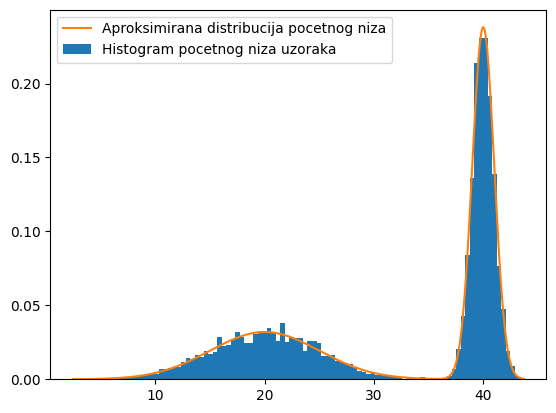

In [54]:
mi1poc = y[0]
mi2poc = y[1]

sigma1poc = np.sqrt(np.var(y))
sigma2poc = sigma1poc

pipoc = 0.5

[mi1_hat, mi2_hat, sigma1_hat, sigma2_hat, pi_hat, k, LL, mi1_niz, mi2_niz, sigma1_niz, sigma2_niz, pi_niz] = EM2GausAlgoritam(y, mi1poc, mi2poc, sigma1poc, sigma2poc, pipoc, 1e-6, 100)
    
#novi parametri koje dobijemo su:
print('mi1_hat =', mi1_hat, 'mi2_hat =', mi2_hat)
print()
print('sigma1_hat^2 =', sigma1_hat**2, 'sigma2_hat^2 =', sigma2_hat**2)
print()
print('pi_hat =', pi_hat)
print()
print('Broj iteracija je', k+1)

PlotajIzvornuIDobivenuFunkciju(y, mi1_hat, mi2_hat, sigma1_hat, sigma2_hat, pi_hat); plt.savefig('primjer2.png');

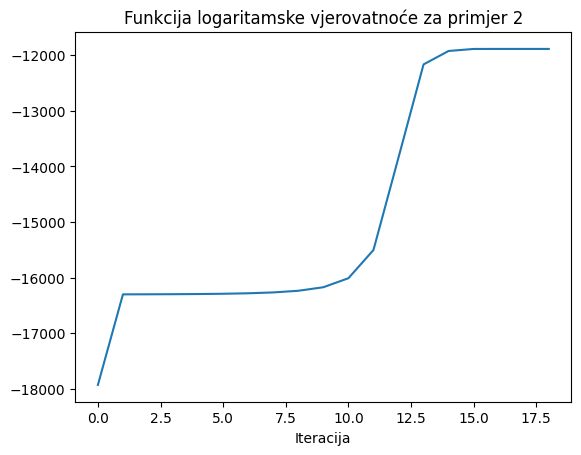

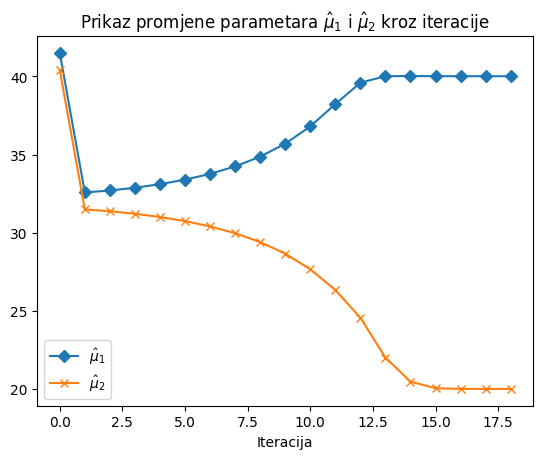

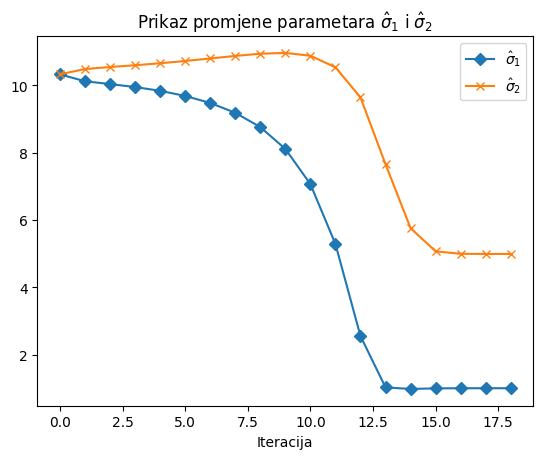

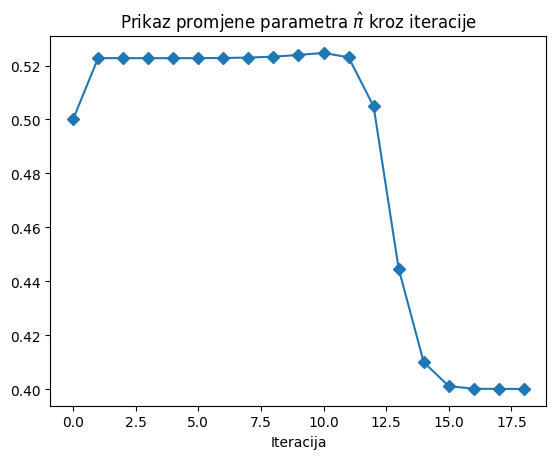

In [55]:
#plot log likelihood funkcije:
plt.figure(); plt.plot(range(0, k+1), LL); plt.title('Funkcija logaritamske vjerovatnoće za primjer 2'); plt.xlabel('Iteracija'); plt.savefig('primjer2_loglikelihood.png');

#kako se parametri mi1 i mi2 mijenjaju kroz iteracije:
plt.figure(); plt.plot(range(0, k+1), mi1_niz, marker = 'D'); plt.plot(range(0, k+1), mi2_niz, marker = 'x'); 
plt.xlabel('Iteracija'); plt.legend(['$\hat{\mu}_1$', '$\hat{\mu}_2$']); plt.title('Prikaz promjene parametara $\hat{\mu}_1$ i $\hat{\mu}_2$ kroz iteracije'); plt.savefig('mi_primjer2.png');

#kako se sigma1 i sigma2 mijenjaju kroz iteracije:
plt.figure(); plt.plot(range(0, k+1), sigma1_niz, marker = 'D'); plt.plot(range(0, k+1), sigma2_niz, marker = 'x');
plt.xlabel('Iteracija'); plt.legend(['$\hat{\sigma}_1$', '$\hat{\sigma}_2$']); plt.title('Prikaz promjene parametara $\hat{\sigma}_1$ i $\hat{\sigma}_2$'); plt.savefig('sigma_primjer2.png');

#kako se pi mijenja kroz iteracije:
plt.figure(); plt.plot(range(0, k+1), pi_niz, marker = 'D'); plt.xlabel('Iteracija'); plt.title('Prikaz promjene parametra $\hat{\pi}$ kroz iteracije'); plt.savefig('pi_primjer2.png');